In [1]:
import os
from pathlib import Path
import torch
import sys

# Add project root to sys.path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from material_aware_flare.eval import extract_flare_channels
from material_aware_flare.utils import save_extracted_channels

# Select the device
device = torch.device('cpu')
devices = 0
if torch.cuda.is_available() and devices >= 0:
    device = torch.device(f'cuda:{devices}')

flame_path = "/home/hleonhard/adl4cv_ws25-26_Relightable-Avatars/external/flare_adl4cv/flame/FLAME2020/generic_model.pkl"

In [2]:
!gcc --version  # Must show gcc-11
!g++ --version  # Must show g++11
!nvcc --version  # shows CUDA 11.6, that is fine now


gcc (Ubuntu 11.5.0-1ubuntu1~24.04) 11.5.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

g++ (Ubuntu 11.5.0-1ubuntu1~24.04) 11.5.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Tue_Mar__8_18:18:20_PST_2022
Cuda compilation tools, release 11.6, V11.6.124
Build cuda_11.6.r11.6/compiler.31057947_0


In [3]:
import sys
sys.path.append("../external/flare_adl4cv") 
from flame.FLAME import FLAME
from flare.core import (
    Mesh, Renderer
)
from flare.modules import (
    NeuralShader, get_deformer_network
)
from flare.utils import (
    AABB, read_mesh,
    save_individual_img, make_dirs, save_relit_intrinsic_materials
)
import nvdiffrec.render.light as light
from flare.dataset import DatasetLoader
from flare.dataset import dataset_util
from flare.metrics import metrics

from arguments import config_parser


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/hleonhard/miniconda3/envs/flare/lib/python3.9/site-packages/torch/utils/cpp_extension.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


In [14]:
!ls /home/hleonhard/data/flare_subject_data/003/train

code.json  flame_params.json  iris.json      mask	       semantic
deca	   image	      keypoint.json  optimize_vis.jpg  semantic_color


In [4]:
config = {
    'config': None,
    # run_name
    'run_name': '001',
    # batch_size
    'batch_size': 2,
    # path
    'input_dir': Path("/home/hleonhard/data/flare_subject_data/001"),
    'train_dir': ["MVI_1814", "MVI_1810"],
    'eval_dir': ["MVI_1812"],
    'working_dir': Path("/home/hleonhard/data/flare_models/"),
    'output_dir': Path("/home/hleonhard/data/flare_models"),
    # misc
    'sample_idx_ratio': 1,
    'device': 0,
    'finetune_color': False,
    # iters
    'iterations': 2000, 
    'final_iter': 1500,
    'upsample_iterations': [500],
    'save_frequency': 300,
    'visualization_frequency': 100,
    'visualization_views': [15, 25, 27, 21, 26],
    # 'downsample' default is set via set_defaults
    'downsample': False,
    'downsample_ratio': 0.03,
    'grad_scale': False, # Default for action='store_true' is False unless set otherwise
    # flame
    'decay_flame': [100],
    'flame_mask': False,
    # lr
    'lr_vertices': 1e-3,
    'lr_shader': 1e-3,
    'lr_deformer': 1e-3,
    # loss weights
    'weight_mask': 2.0,
    'weight_normal': 0.1,
    'weight_laplacian': 60.0,
    'weight_shading': 1.0,
    'weight_perceptual_loss': 0.1,
    'weight_albedo_regularization': 0.01,
    'weight_flame_regularization': 10.0,
    'weight_white_lgt_regularization': 1.0,
    'weight_roughness_regularization': 0.1,
    'weight_fresnel_coeff': 0.01,
    'r_mean': 0.500,
    # neural shader
    'fourier_features': 'positional',
    'activation': 'relu',
    'bsdf': 'pbr_shading',
    'deform_d_out': 128,
    'light_mlp_ch': 3,
    'light_mlp_dims': [64, 64],
    'material_mlp_dims': [128, 128, 128, 128],
    'material_mlp_ch': 4,
    # ghostbone/train_deformer (defaults are set via set_defaults)
    'ghostbone': True,
    'train_deformer': True,
    'deform_dims': [128, 128, 128, 128]
}


subject = 1

new_values_1 = {
    'run_name': '',
    'input_dir': Path("/home/hleonhard/data/flare_subject_data/001"),
    'train_dir': ["MVI_1814", "MVI_1810"],
    'eval_dir': ["MVI_1812"],
    'working_dir': Path("/home/hleonhard/data/flare_models/"),
    'output_dir': Path("/home/hleonhard/data/flare_models/001/MVI_1812"),
    'batch_size': 1,
    'sample_idx_ratio': 1,
    'iterations': 1500,
    'upsample_iterations': [500],
    'lr_deformer': 1e-3,
    'lr_shader': 1e-3,
    'lr_vertices': 1e-3,
    'weight_shading': 1.0,
    'weight_perceptual_loss': 0.1,
    'weight_mask': 2.0,
    'weight_albedo_regularization': 0.01,
    'weight_white_lgt_regularization': 0.01,
    'weight_roughness_regularization': 0.01,
    'weight_fresnel_coeff': 0.01,
    'weight_normal': 0.1,
    'weight_laplacian': 60.0,
    'light_mlp_ch': 3,
    'light_mlp_dims': [64, 64],
    'material_mlp_dims': [128, 128, 128, 128],
    'material_mlp_ch': 5
}

if subject == 1:
  config.update(new_values_1)

from types import SimpleNamespace
config = SimpleNamespace(**config)

In [5]:
images_save_path, images_eval_save_path, meshes_save_path, shaders_save_path, experiment_dir = make_dirs(
    config, config.run_name, config.finetune_color
  )
dataset_val = DatasetLoader(config, train_dir=config.eval_dir, sample_ratio=config.sample_idx_ratio, pre_load=False)
dataloader_validate = torch.utils.data.DataLoader(dataset_val, batch_size=4, collate_fn=dataset_val.collate, shuffle=False)

In [6]:
flame_shape = dataset_val.shape_params
FLAMEServer = FLAME(flame_path, n_shape=100, n_exp=50, shape_params=flame_shape).to(device)

creating the FLAME Decoder


In [7]:
### Obtain the initial mesh and compute its connectivity
flame_canonical_mesh = Mesh(FLAMEServer.v_template, FLAMEServer.faces_tensor, device=device)
flame_canonical_mesh.compute_connectivity()
### create bounding box from the mesh vertices
aabb = AABB(flame_canonical_mesh.vertices.cpu().numpy())
flame_mesh_aabb = [torch.min(flame_canonical_mesh.vertices, dim=0).values, torch.max(flame_canonical_mesh.vertices, dim=0).values]
# init mesh is mouth open!!!
FLAMEServer.canonical_exp = dataset_val.get_mean_expression_train(config.train_dir).to(device)
FLAMEServer.canonical_pose = FLAMEServer.canonical_pose.to(device)
FLAMEServer.canonical_verts, FLAMEServer.canonical_pose_feature, FLAMEServer.canonical_transformations = \
    FLAMEServer(expression_params=FLAMEServer.canonical_exp, full_pose=FLAMEServer.canonical_pose)
FLAMEServer.canonical_verts = FLAMEServer.canonical_verts.to(device)
flame_canonical_mesh.vertices = FLAMEServer.canonical_verts.squeeze(0)

In [8]:
experiment_dir

PosixPath('/home/hleonhard/data/flare_models/001/MVI_1812')

In [10]:
experiment_dir = Path('/home/hleonhard/data/flare_models/001')

In [11]:
# ==============================================================================================
# mesh
# ==============================================================================================
mesh_path = Path(experiment_dir / "stage_1" / "meshes" / f"mesh_latest.obj")
mesh = read_mesh(mesh_path, device=device)
mesh.compute_connectivity()
mesh.to(device)

In [12]:
# ==============================================================================================
# Rendererrr
# ==============================================================================================
renderer = Renderer(device=device)
renderer.set_near_far(dataset_val, torch.from_numpy(aabb.corners).to(device), epsilon=0.5)
channels_gbuffer = ['mask', 'position', 'normal', "canonical_position"]

In [13]:
# ==============================================================================================
# deformation
# ==============================================================================================
load_deformer = Path(experiment_dir / "stage_2" / "network_weights" / f"deformer_latest.pt")
assert os.path.exists(load_deformer)
multires = 0
deformer_net = get_deformer_network(FLAMEServer, model_path=load_deformer, train=False, d_in=3, dims=[128, 128, 128, 128],
                                       weight_norm=True, multires=multires, num_exp=50, aabb=aabb, ghostbone=config.ghostbone, device=device)
if config.ghostbone:
    FLAMEServer.canonical_transformations = torch.cat([torch.eye(4).unsqueeze(0).unsqueeze(0).float().to(device), FLAMEServer.canonical_transformations], 1)

In [14]:
# ==============================================================================================
# shading
# ==============================================================================================
load_shader = Path(experiment_dir / "stage_2" / "network_weights" / f"shader_latest.pt")
assert os.path.exists(load_shader)
shader = NeuralShader.load(load_shader, device=device)
lgt = light.create_env_rnd()
print("=="*50)
shader.eval()
deformer_net.eval()
batch_size = config.batch_size
print("Batch Size:", batch_size)

STAGE 2: Using hashgrid (tinycudann) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [64, 64], 'light_mlp_dims': [64, 64]}
Batch Size: 1


In [15]:
# ==============================================================================================
# evaluation
# ==============================================================================================
def run(
    args,
    mesh,
    views,
    FLAMEServer,
    deformer_net,
    shader,
    renderer,
    device,
    channels_gbuffer,
    lgt,
):
    ## ============== deform ==============================
    shapedirs, posedirs, lbs_weights = deformer_net.query_weights(mesh.vertices)
    eval_vertices = mesh.vertices
    batched_verts = eval_vertices.unsqueeze(0).repeat(views["img"].shape[0], 1, 1)

    _, pose_features, transformations = FLAMEServer(
        expression_params=views["flame_expression"], full_pose=views["flame_pose"]
    )
    if args.ghostbone:
        transformations = torch.cat(
            [
                torch.eye(4)
                .unsqueeze(0)
                .unsqueeze(0)
                .expand(views["img"].shape[0], -1, -1, -1)
                .float()
                .to(device),
                transformations,
            ],
            1,
        )
    deformed_vertices = FLAMEServer.forward_pts_batch(
        pnts_c=batched_verts,
        betas=views["flame_expression"],
        transformations=transformations,
        pose_feature=pose_features,
        shapedirs=shapedirs,
        posedirs=posedirs,
        lbs_weights=lbs_weights,
        dtype=torch.float32,
        map2_flame_original=True,
    )

    d_normals = mesh.fetch_all_normals(deformed_vertices, mesh)
    ## ============== Rasterize ==============================
    gbuffers = renderer.render_batch(
        views["camera"],
        deformed_vertices.contiguous(),
        d_normals,
        channels=channels_gbuffer,
        with_antialiasing=True,
        canonical_v=mesh.vertices,
        canonical_idx=mesh.indices,
    )

    ## ============== predict color ==============================
    rgb_pred, cbuffers, gbuffer_mask = shader.shade(
        gbuffers, views, mesh, args.finetune_color, lgt
    )

    return rgb_pred, gbuffers, cbuffers


# ==============================================================================================
# relight: run
# ==============================================================================================
def run_relight(
    args,
    mesh,
    views,
    FLAMEServer,
    deformer_net,
    shader,
    renderer,
    device,
    channels_gbuffer,
    lgt_list,
    images_save_path,
):
    ## ============== deform ==============================
    shapedirs, posedirs, lbs_weights = deformer_net.query_weights(mesh.vertices)
    eval_vertices = mesh.vertices
    batched_verts = eval_vertices.unsqueeze(0).repeat(views["img"].shape[0], 1, 1)

    _, pose_features, transformations = FLAMEServer(
        expression_params=views["flame_expression"], full_pose=views["flame_pose"]
    )
    if args.ghostbone:
        transformations = torch.cat(
            [
                torch.eye(4)
                .unsqueeze(0)
                .unsqueeze(0)
                .expand(views["img"].shape[0], -1, -1, -1)
                .float()
                .to(device),
                transformations,
            ],
            1,
        )
    deformed_vertices = FLAMEServer.forward_pts_batch(
        pnts_c=batched_verts,
        betas=views["flame_expression"],
        transformations=transformations,
        pose_feature=pose_features,
        shapedirs=shapedirs,
        posedirs=posedirs,
        lbs_weights=lbs_weights,
        dtype=torch.float32,
        map2_flame_original=True,
    )

    d_normals = mesh.fetch_all_normals(deformed_vertices, mesh)
    ## ============== Rasterize ==============================
    gbuffers = renderer.render_batch(
        views["camera"],
        deformed_vertices.contiguous(),
        d_normals,
        channels=channels_gbuffer,
        with_antialiasing=True,
        canonical_v=mesh.vertices,
        canonical_idx=mesh.indices,
    )

    ## ============== predict color ==============================
    relit_imgs, cbuffers, gbuffer_mask = shader.relight(
        gbuffers, views, mesh, args.finetune_color, lgt_list
    )
    save_relit_intrinsic_materials(
        relit_imgs, views, gbuffer_mask, cbuffers, images_save_path
    )

In [ ]:
# import shutil
# import os
# 
# cache_dir = os.path.expanduser("~/.cache/torch_extensions")
# print("Removing:", cache_dir)
# shutil.rmtree(cache_dir, ignore_errors=True)

Removing: /home/hleonhard/.cache/torch_extensions


In [16]:
def quantitative_eval_flare(
    args,
    mesh,
    dataloader_validate,
    FLAMEServer,
    deformer_net,
    shader,
    renderer,
    device,
    channels_gbuffer,
    experiment_dir,
    images_eval_save_path,
    lgt=None,
    save_each=False,
):

    for it, views_subset in enumerate(dataloader_validate):
        with torch.no_grad():
            rgb_pred, gbuffer, cbuffer = run(
                args,
                mesh,
                views_subset,
                FLAMEServer,
                deformer_net,
                shader,
                renderer,
                device,
                channels_gbuffer,
                lgt=lgt,
            )
            extracted_channels = extract_flare_channels(
                shader, gbuffer, views_subset, mesh
            )
            print(f"extracted channels")
            break
        save_extracted_channels(
            extracted_channels, views_subset["img_idx"], images_eval_save_path
        )
        rgb_pred = rgb_pred * gbuffer["mask"]

In [17]:
images_eval_save_path

PosixPath('/home/hleonhard/data/flare_models/001/MVI_1812/images_evaluation')

In [18]:
from tqdm.notebook import tqdm


for it, views_subset in tqdm(enumerate(dataloader_validate), total=len(dataloader_validate)):
    with torch.no_grad():
        rgb_pred, gbuffer, cbuffer = run(
            config,
            mesh,
            views_subset,
            FLAMEServer,
            deformer_net,
            shader,
            renderer,
            device,
            channels_gbuffer,
            lgt=lgt,
        )
        extracted_channels = extract_flare_channels(
            shader, gbuffer, views_subset, mesh
        )
    save_extracted_channels(
        extracted_channels, views_subset["idx"], images_eval_save_path
    )
    rgb_pred = rgb_pred * gbuffer["mask"]


  0%|          | 0/456 [00:00<?, ?it/s]

Using /home/hleonhard/.cache/torch_extensions/py39_cu116 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/hleonhard/.cache/torch_extensions/py39_cu116/renderutils_plugin/build.ninja...
Building extension module renderutils_plugin...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)
Loading extension module renderutils_plugin...


ninja: no work to do.


In [20]:
!ls /home/hleonhard/data/flare_models/001/MVI_1812/images_evaluation/albedo

0000.png  0228.png  0456.png  0684.png	0912.png  1140.png  1368.png  1596.png
0001.png  0229.png  0457.png  0685.png	0913.png  1141.png  1369.png  1597.png
0002.png  0230.png  0458.png  0686.png	0914.png  1142.png  1370.png  1598.png
0003.png  0231.png  0459.png  0687.png	0915.png  1143.png  1371.png  1599.png
0004.png  0232.png  0460.png  0688.png	0916.png  1144.png  1372.png  1600.png
0005.png  0233.png  0461.png  0689.png	0917.png  1145.png  1373.png  1601.png
0006.png  0234.png  0462.png  0690.png	0918.png  1146.png  1374.png  1602.png
0007.png  0235.png  0463.png  0691.png	0919.png  1147.png  1375.png  1603.png
0008.png  0236.png  0464.png  0692.png	0920.png  1148.png  1376.png  1604.png
0009.png  0237.png  0465.png  0693.png	0921.png  1149.png  1377.png  1605.png
0010.png  0238.png  0466.png  0694.png	0922.png  1150.png  1378.png  1606.png
0011.png  0239.png  0467.png  0695.png	0923.png  1151.png  1379.png  1607.png
0012.png  0240.png  0468.png  0696.png	0924.png  1152.png  1380.

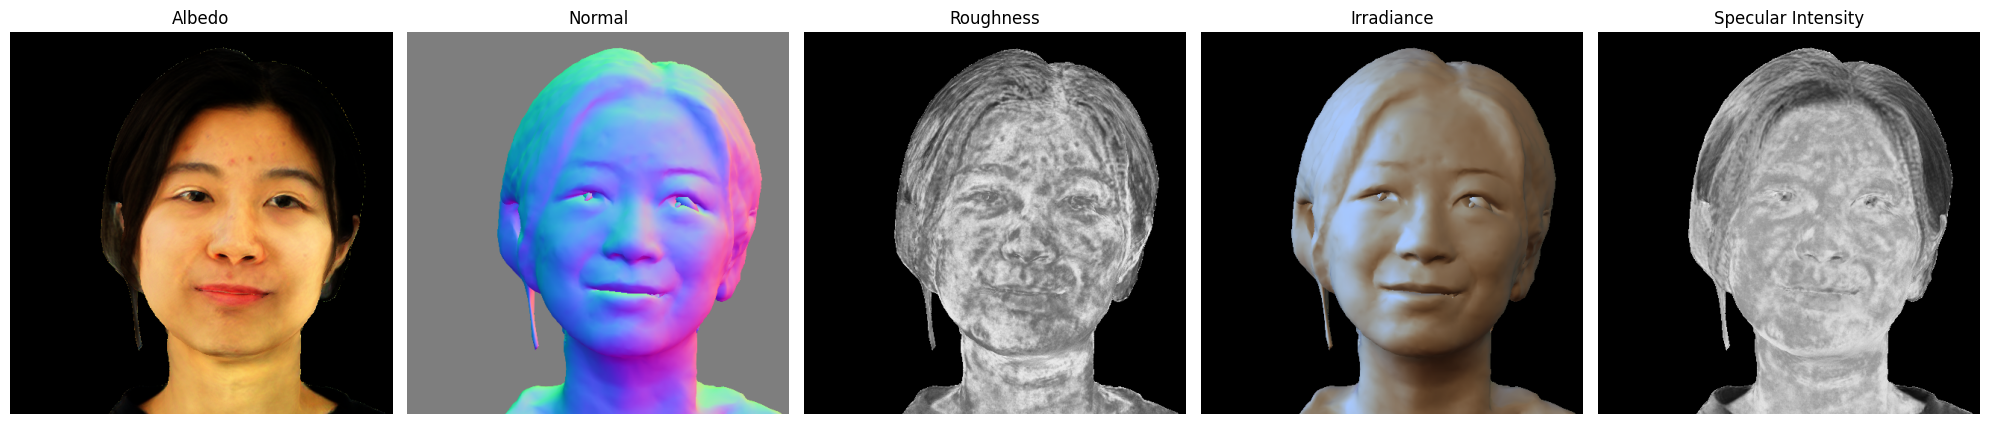

In [24]:
import torch
import matplotlib.pyplot as plt

def tensor_to_numpy(img):
    """img: (H, W, C) tensor in [0,1] or any range. Returns uint8 numpy."""
    img = img.detach().cpu()
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]

    # Normalize each channel independently for visualization if needed
    img_min, img_max = img.min(), img.max()
    if (img_max - img_min) > 1e-6:
        img = (img - img_min) / (img_max - img_min)

    img = (img * 255).clamp(0, 255).byte().numpy()
    return img


def plot_flare_channels(extracted):
    """
    extracted: dict returned by extract_flare_channels()
               each entry is (B, H, W, C)
    """

    # use first batch element B=0
    albedo = extracted["albedo"][0]          # (H,W,3)
    normal = extracted["normal"][0]          # (H,W,3)
    rough  = extracted["roughness"][0]       # (H,W,1)
    irr    = extracted["irradiance"][0]      # (H,W,3)
    spec   = extracted["specular_intensity"][0]  # (H,W,1)

    # Convert all to numpy for plotting
    albedo_np = tensor_to_numpy(albedo)
    normal_np = tensor_to_numpy(normal)
    rough_np  = tensor_to_numpy(rough)
    irr_np    = tensor_to_numpy(irr)
    spec_np   = tensor_to_numpy(spec)

    # Build figure
    fig, axs = plt.subplots(1, 5, figsize=(20, 5))

    axs[0].imshow(albedo_np)
    axs[0].set_title("Albedo")
    axs[0].axis('off')

    axs[1].imshow(normal_np)
    axs[1].set_title("Normal")
    axs[1].axis('off')

    axs[2].imshow(rough_np, cmap="gray")
    axs[2].set_title("Roughness")
    axs[2].axis('off')

    axs[3].imshow(irr_np)
    axs[3].set_title("Irradiance")
    axs[3].axis('off')

    axs[4].imshow(spec_np, cmap="gray")
    axs[4].set_title("Specular Intensity")
    axs[4].axis('off')

    plt.tight_layout()
    plt.show()

plot_flare_channels(extracted_channels)

In [ ]:
!ls /home/hleonhard/data/flare_subject_data/001/MVI_1814/image/660.png

/home/hleonhard/data/flare_subject_data/001/MVI_1814/image/660.png


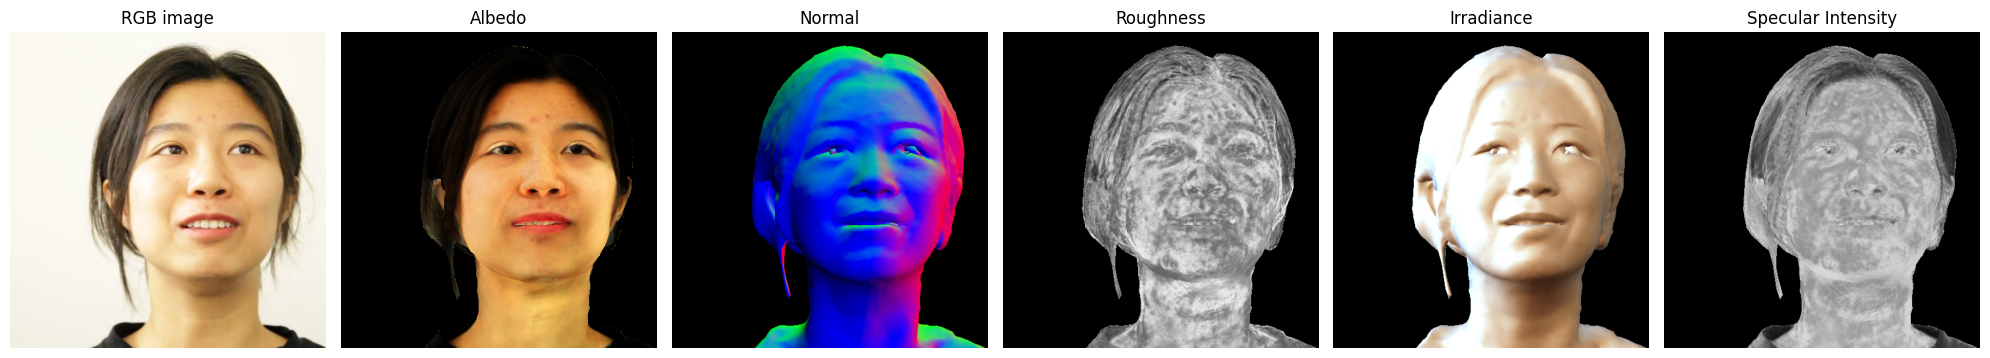

In [43]:
import matplotlib.pyplot as plt

img = plt.imread('/home/hleonhard/data/flare_subject_data/001/MVI_1814/image/660.png')
img1 = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/albedo/0660.png')
img2 = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/normal/0660.png')
img3 = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/roughness/0660.png')
img4 = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/irradiance/0660.png')
img5 = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/specular_intensity/0660.png')

fig, axs = plt.subplots(1, 6, figsize=(20, 5))
axs[0].imshow(img)
axs[0].set_title("RGB image")
axs[0].axis('off')
axs[1].imshow(img1)
axs[1].set_title("Albedo")
axs[1].axis('off')
axs[2].imshow(img2)
axs[2].set_title("Normal")
axs[2].axis('off')
axs[3].imshow(img3, cmap="gray")
axs[3].set_title("Roughness")
axs[3].axis('off')
axs[4].imshow(img4)
axs[4].set_title("Irradiance")
axs[4].axis('off')
axs[5].imshow(img5, cmap="gray")
axs[5].set_title("Specular Intensity")
axs[5].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================================
# evaluation: intrinsic materials and relighting
# ==============================================================================================
lgt_list = light.load_target_cubemaps(config.working_dir)
for i in range(len(lgt_list)):
    Path(images_eval_save_path / "qualitative_results" / f"env_map_{i}" ).mkdir(parents=True, exist_ok=True)
for it, views_subset in enumerate(dataloader_validate):
    with torch.no_grad():
        quantitative_eval_flare(config, mesh, views_subset, FLAMEServer, deformer_net, shader, renderer, device, channels_gbuffer, lgt_list, images_eval_save_path / "qualitative_results")
        # run_relight(config, mesh, views_subset, FLAMEServer, deformer_net, shader, renderer, device, channels_gbuffer, lgt_list, images_eval_save_path / "qualitative_results")